# CFPB Complaint Operations Analysis (Post-ETL)

## Objective and Business Context

**Stakeholder:** Complaint Operations Leadership

**Operational Problem:**  
Complaint handling demand is concentrated in a small set of product and issue segments, while untimely risk and operational burden are unevenly distributed.

**Analytical Objective:**  
Identify where operational burden and untimely risk are concentrated, then prioritize product–issue–channel segments for practical intervention.

**Data Context:**  
This analysis uses **cleaned post-ETL outputs** from CFPB published complaint records.  
CFPB records are published after company response or after 15 days, so this dataset is useful for portfolio-level operational analysis but **does not represent full internal workflow telemetry** (e.g., queue transitions, staffing allocation, handoffs, or true resolution lifecycle).

# Data Loading and Setup

In [ ]:
# %%
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# -----------------------------
# Display and plotting settings
# -----------------------------
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["legend.fontsize"] = 10

# -----------------------------
# Helper functions
# -----------------------------
def fmt_pct(x, decimals=1):
    if pd.isna(x):
        return "NA"
    return f"{x*100:.{decimals}f}%"

def fmt_int(x):
    if pd.isna(x):
        return "NA"
    return f"{int(round(x)):,}"

def ensure_columns(df, required_cols):
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns for analysis: {missing}")

def grouped_metrics(df, group_col):
    out = (
        df.groupby(group_col, dropna=False)
          .agg(
              complaints=("complaint_id", "count"),
              untimely_rate=("untimely_flag", "mean"),
              median_intake_to_routing_days=("intake_to_routing_days", "median"),
              median_days_since_received=("days_since_received", "median"),
          )
          .reset_index()
          .sort_values("complaints", ascending=False)
    )
    return out

# -----------------------------
# Configuration
# -----------------------------
clean_dir = Path("data/clean")

# Main stage artifacts from final pipeline
parquet_path = clean_dir / "stg_complaints_scoped.parquet"
csv_path = clean_dir / "stg_complaints_scoped_postgres.csv"
sample_path = clean_dir / "sample_scoped_100k.csv"

# Bridge artifacts (optional for this notebook, but paths are defined explicitly)
bridge_parquet_path = clean_dir / "bridge_complaint_tag_scoped.parquet"
bridge_csv_path = clean_dir / "bridge_complaint_tag_scoped_postgres.csv"

USE_SAMPLE = True      # True for faster notebook iteration
USE_PARQUET = True     # Used only when USE_SAMPLE=False

# -----------------------------
# Load main dataset robustly
# -----------------------------
if USE_SAMPLE:
    if not sample_path.exists():
        raise FileNotFoundError(f"Sample file not found: {sample_path}")
    df = pd.read_csv(sample_path)
    data_source = f"sample_csv: {sample_path.name}"
else:
    if USE_PARQUET:
        if not parquet_path.exists():
            raise FileNotFoundError(f"Parquet file not found: {parquet_path}")
        df = pd.read_parquet(parquet_path)
        data_source = f"parquet: {parquet_path.name}"
    else:
        if not csv_path.exists():
            raise FileNotFoundError(f"CSV file not found: {csv_path}")
        df = pd.read_csv(csv_path)
        data_source = f"csv: {csv_path.name}"

# Parse date columns safely if present
for c in ["date_received", "date_sent_to_company", "as_of_date"]:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors="coerce")

# Optional bridge load
bridge = None
if bridge_parquet_path.exists() and USE_PARQUET and not USE_SAMPLE:
    bridge = pd.read_parquet(bridge_parquet_path)
elif bridge_csv_path.exists():
    bridge = pd.read_csv(bridge_csv_path)

print(f"Loaded source: {data_source}")
print(f"Main dataset shape: {df.shape}")
if bridge is not None:
    print(f"Bridge dataset shape: {bridge.shape}")
else:
    print("Bridge dataset not loaded (optional for current analysis).")

Loaded source: sample_csv: sample_scoped_100k.csv
Main dataset shape: (100000, 35)
Bridge dataset shape: (257594, 2)


## Data Validation and Key Field Check

Before analysis, we verify that all required fields are available and inspect the dataset structure.  
This prevents downstream chart or metric failures and ensures reproducibility.

In [2]:
# %%
required_fields = [
    "complaint_id",
    "date_received",
    "product_domain",
    "issue_std",
    "channel_std",
    "timely_flag",
    "untimely_flag",
    "days_since_received",
    "heavy_channel_flag",
    "effort_score",
    "effort_unknown_flag",
    "intake_to_routing_days",
    "narrative_length_chars",
]

ensure_columns(df, required_fields)

print("✅ Required analysis fields are present.")
print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns):,}\n")

display(df.head(5))
print("Columns loaded:")
print(df.columns.tolist())

✅ Required analysis fields are present.
Rows: 100,000
Columns: 35



,complaint_id,date_received,date_sent_to_company,as_of_date,company_raw,company_std,product_raw,product_std,product_domain,domain_is_focus_flag,issue_raw,issue_std,sub_product_std,sub_issue_std,state,zip3,zip5,channel_std,company_response_to_consumer,company_public_response,timely_flag,disputed_flag,has_narrative_flag,narrative_length_chars,intake_to_routing_days,lag_negative_flag,days_since_received,days_since_received_bucket,heavy_channel_flag,consent_std,long_narrative_flag,untimely_flag,dispute_flag,effort_score,effort_unknown_flag
0,16315903,2025-10-02,2025-10-02,2026-04-24,Experian Information Solutions Inc.,EXPERIAN INFORMATION SOLUTIONS INC.,Credit reporting or other personal consumer re...,credit reporting or other personal consumer re...,Credit Reporting,1,Incorrect information on your report,Incorrect information on your report,Credit reporting,Account status incorrect,CA,913.0000,"91,303.0000",web,Closed with explanation,Company has responded to the consumer and the ...,1,NaN,0,NaN,0,0,204,60+,0,other,NaN,0,NaN,0,1
1,7887411,2023-11-21,2023-11-21,2026-04-24,"TRANSUNION INTERMEDIATE HOLDINGS, INC.","TRANSUNION INTERMEDIATE HOLDINGS, INC.",Credit reporting or other personal consumer re...,credit reporting or other personal consumer re...,Credit Reporting,1,Improper use of your report,Improper use of your report,Credit reporting,Reporting company used your report improperly,IN,NaN,NaN,web,Closed with non-monetary relief,Company has responded to the consumer and the ...,1,NaN,1,899.0000,0,0,885,60+,0,consent provided,0.0000,0,NaN,0,1
2,13734813,2025-05-28,2025-05-28,2026-04-24,"EQUIFAX, INC.","EQUIFAX, INC.",Credit reporting or other personal consumer re...,credit reporting or other personal consumer re...,Credit Reporting,1,Problem with a company's investigation into an...,Problem with a company's investigation into an...,Credit reporting,Their investigation did not fix an error on yo...,FL,331.0000,"33,157.0000",web,Closed with non-monetary relief,NaN,1,NaN,0,NaN,0,0,331,60+,0,consent not provided,NaN,0,NaN,0,1
3,16372178,2025-10-06,2025-10-06,2026-04-24,TRANSWORLD SYSTEMS INC,TRANSWORLD SYSTEMS INC,Debt collection,debt collection,Debt Collection,1,Attempts to collect debt not owed,Attempts to collect debt not owed,I do not know,Debt was result of identity theft,NV,890.0000,"89,031.0000",web,Closed with explanation,NaN,1,NaN,1,"1,390.0000",0,0,200,60+,0,consent provided,1.0000,0,NaN,1,1
4,17186847,2025-11-12,2025-11-12,2026-04-24,"EQUIFAX, INC.","EQUIFAX, INC.",Credit reporting or other personal consumer re...,credit reporting or other personal consumer re...,Credit Reporting,1,Incorrect information on your report,Incorrect information on your report,Credit reporting,Account status incorrect,CT,61.0000,"6,106.0000",web,In progress,NaN,1,NaN,0,NaN,0,0,163,60+,0,NaN,NaN,0,NaN,0,1


Columns loaded:
['complaint_id', 'date_received', 'date_sent_to_company', 'as_of_date', 'company_raw', 'company_std', 'product_raw', 'product_std', 'product_domain', 'domain_is_focus_flag', 'issue_raw', 'issue_std', 'sub_product_std', 'sub_issue_std', 'state', 'zip3', 'zip5', 'channel_std', 'company_response_to_consumer', 'company_public_response', 'timely_flag', 'disputed_flag', 'has_narrative_flag', 'narrative_length_chars', 'intake_to_routing_days', 'lag_negative_flag', 'days_since_received', 'days_since_received_bucket', 'heavy_channel_flag', 'consent_std', 'long_narrative_flag', 'untimely_flag', 'dispute_flag', 'effort_score', 'effort_unknown_flag']


# KPI Summary

In [3]:
# %%
# Historical age buckets (contextual, not backlog)
age_bins = [-1, 30, 90, 180, 365, np.inf]
age_labels = ["0–30", "31–90", "91–180", "181–365", "365+"]
df["age_bucket_hist"] = pd.cut(
    df["days_since_received"].astype("float"),
    bins=age_bins,
    labels=age_labels
)

total_complaints = len(df)
timely_rate = df["timely_flag"].mean()
untimely_rate = df["untimely_flag"].mean()
median_intake_to_routing = df["intake_to_routing_days"].median()
median_age = df["days_since_received"].median()
older_share_hist = df["age_bucket_hist"].astype("string").isin(["181–365", "365+"]).mean()

# Keep effort score with explicit caution (derived proxy only)
avg_effort_proxy = df["effort_score"].mean()

kpi_summary = pd.DataFrame({
    "KPI": [
        "Total complaints",
        "Timely rate",
        "Untimely rate",
        "Median intake_to_routing_days",
        "Median days_since_received",
        "Share in older historical age buckets (181–365, 365+)",
        "Average effort score (derived proxy)",
    ],
    "Value": [
        fmt_int(total_complaints),
        fmt_pct(timely_rate),
        fmt_pct(untimely_rate),
        f"{median_intake_to_routing:.1f}" if pd.notna(median_intake_to_routing) else "NA",
        f"{median_age:.1f}" if pd.notna(median_age) else "NA",
        fmt_pct(older_share_hist),
        f"{avg_effort_proxy:.2f}" if pd.notna(avg_effort_proxy) else "NA",
    ],
})

display(kpi_summary)

,KPI,Value
0,Total complaints,"100,000"
1,Timely rate,99.8%
2,Untimely rate,0.2%
3,Median intake_to_routing_days,0.0
4,Median days_since_received,407.0
5,Share in older historical age buckets (181–365...,87.8%
6,Average effort score (derived proxy),0.07


# Volume Analysis

,product_domain,complaints,share
0,Credit Reporting,91973,0.9197
1,Debt Collection,5414,0.0541
2,Checking / Savings,1959,0.0196
3,Mortgage,654,0.0065


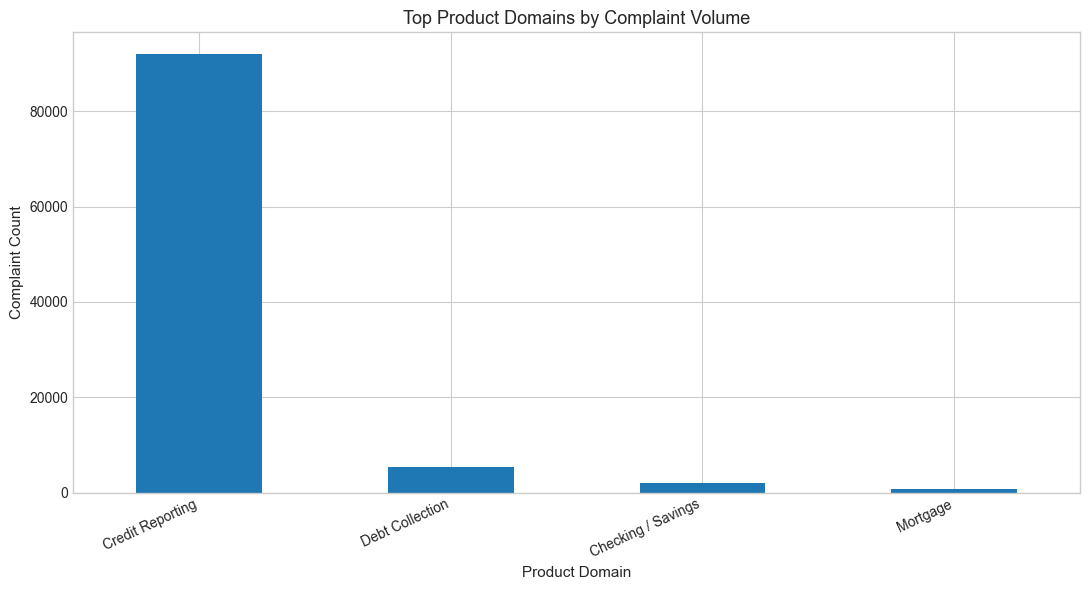

,issue_std,complaints
0,Incorrect information on your report,50233
1,Improper use of your report,23545
2,Problem with a company's investigation into an...,16099
3,Attempts to collect debt not owed,2292
4,Written notification about debt,1439
5,Problem with a credit reporting company's inve...,1199
6,Managing an account,1080
7,False statements or representation,668
8,Took or threatened to take negative or legal a...,659
9,Trouble during payment process,349


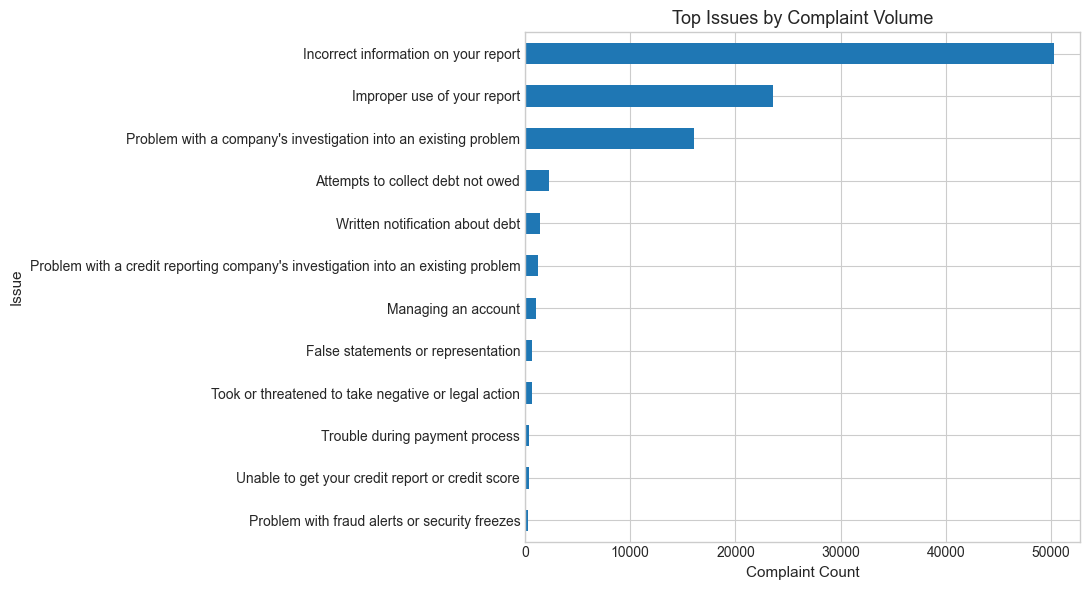

,product_domain,issue_std,complaints
15,Credit Reporting,Incorrect information on your report,50211
14,Credit Reporting,Improper use of your report,23538
17,Credit Reporting,Problem with a company's investigation into an...,16090
22,Debt Collection,Attempts to collect debt not owed,2292
28,Debt Collection,Written notification about debt,1439
18,Credit Reporting,Problem with a credit reporting company's inve...,1198
3,Checking / Savings,Managing an account,1080
25,Debt Collection,False statements or representation,668
27,Debt Collection,Took or threatened to take negative or legal a...,659
36,Mortgage,Trouble during payment process,349


In [4]:
# %%
# Volume by product domain
vol_product = (
    df.groupby("product_domain", dropna=False)["complaint_id"]
      .count()
      .rename("complaints")
      .sort_values(ascending=False)
      .reset_index()
)
vol_product["share"] = vol_product["complaints"] / vol_product["complaints"].sum()
display(vol_product.head(15))

ax = vol_product.head(10).plot(
    kind="bar",
    x="product_domain",
    y="complaints",
    legend=False,
    title="Top Product Domains by Complaint Volume"
)
ax.set_xlabel("Product Domain")
ax.set_ylabel("Complaint Count")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

# Volume by issue
vol_issue = (
    df.groupby("issue_std", dropna=False)["complaint_id"]
      .count()
      .rename("complaints")
      .sort_values(ascending=False)
      .reset_index()
)
display(vol_issue.head(15))

ax = vol_issue.head(12).sort_values("complaints", ascending=True).plot(
    kind="barh",
    x="issue_std",
    y="complaints",
    legend=False,
    title="Top Issues by Complaint Volume"
)
ax.set_xlabel("Complaint Count")
ax.set_ylabel("Issue")
plt.tight_layout()
plt.show()

# Top product + issue combinations
combo = (
    df.groupby(["product_domain", "issue_std"], dropna=False)["complaint_id"]
      .count()
      .rename("complaints")
      .reset_index()
      .sort_values("complaints", ascending=False)
)
display(combo.head(20))

# Untimely / SLA Risk Analysis

,product_domain,complaints,untimely_rate,median_intake_to_routing_days,median_days_since_received
1,Credit Reporting,91973,0.0011,0.0000,402.0000
2,Debt Collection,5414,0.0198,0.0000,428.0000
0,Checking / Savings,1959,0.0097,0.0000,486.0000
3,Mortgage,654,0.0061,0.0000,542.0000


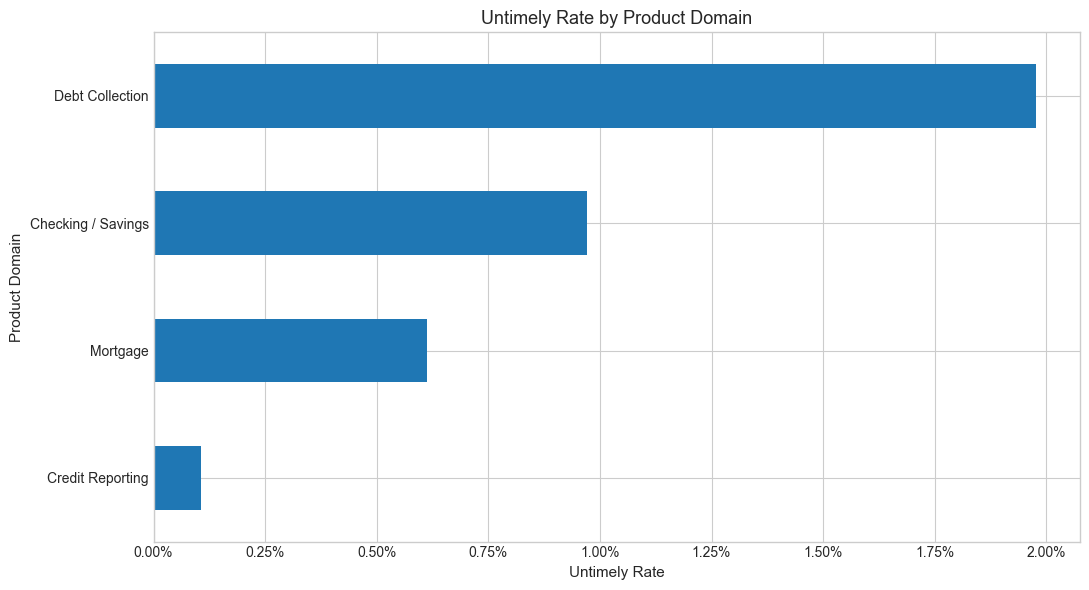

,issue_std,complaints,untimely_rate,median_intake_to_routing_days,median_days_since_received
13,Incorrect information on your report,50233,0.0010,0.0000,378.0000
12,Improper use of your report,23545,0.0015,0.0000,446.0000
18,Problem with a company's investigation into an...,16099,0.0006,0.0000,401.0000
1,Attempts to collect debt not owed,2292,0.0223,0.0000,448.0000
27,Written notification about debt,1439,0.0111,0.0000,465.0000
19,Problem with a credit reporting company's inve...,1199,0.0008,0.0000,"1,030.0000"
14,Managing an account,1080,0.0102,0.0000,496.5000
9,False statements or representation,668,0.0210,0.0000,375.0000
24,Took or threatened to take negative or legal a...,659,0.0258,0.0000,294.0000
25,Trouble during payment process,349,0.0000,0.0000,527.0000


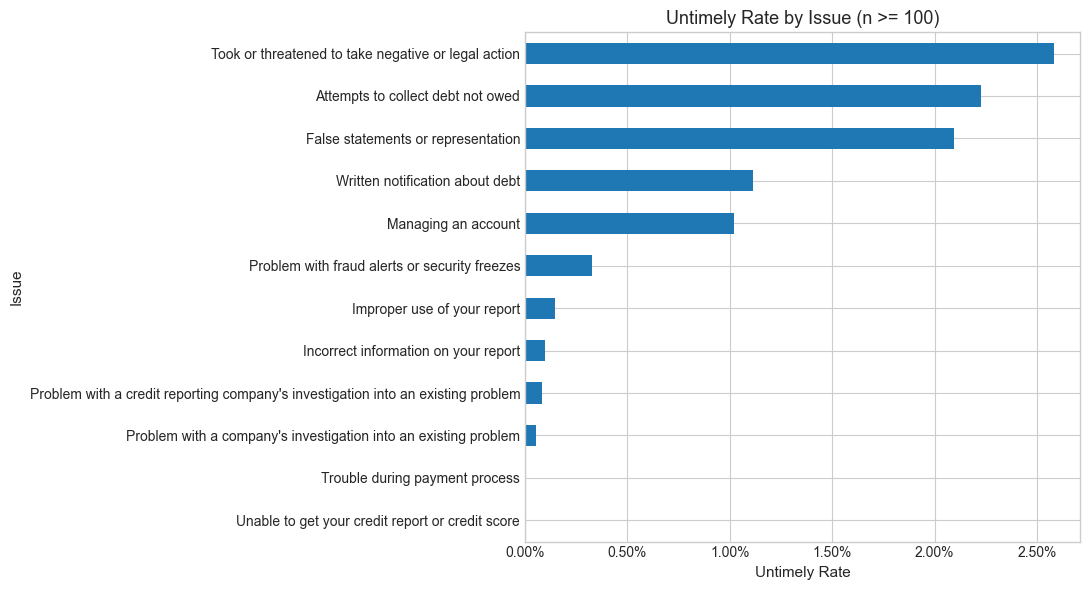

In [5]:
# %%
# Untimely risk by product domain
timeliness_by_product = grouped_metrics(df, "product_domain")
display(timeliness_by_product.head(15))

ax = timeliness_by_product.sort_values("untimely_rate", ascending=True).plot(
    kind="barh",
    x="product_domain",
    y="untimely_rate",
    legend=False,
    title="Untimely Rate by Product Domain"
)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlabel("Untimely Rate")
ax.set_ylabel("Product Domain")
plt.tight_layout()
plt.show()

# Untimely risk by issue with stability filter
timeliness_by_issue = grouped_metrics(df, "issue_std")
timeliness_by_issue = timeliness_by_issue[timeliness_by_issue["complaints"] >= 100].copy()

display(timeliness_by_issue.head(20))

ax = timeliness_by_issue.head(12).sort_values("untimely_rate", ascending=True).plot(
    kind="barh",
    x="issue_std",
    y="untimely_rate",
    legend=False,
    title="Untimely Rate by Issue (n >= 100)"
)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlabel("Untimely Rate")
ax.set_ylabel("Issue")
plt.tight_layout()
plt.show()

# Channel Analysis

,channel_std,complaints,share
0,web,99212,0.9921
1,phone,407,0.0041
2,referral,191,0.0019
3,postal mail,186,0.0019
4,other,4,0.0000


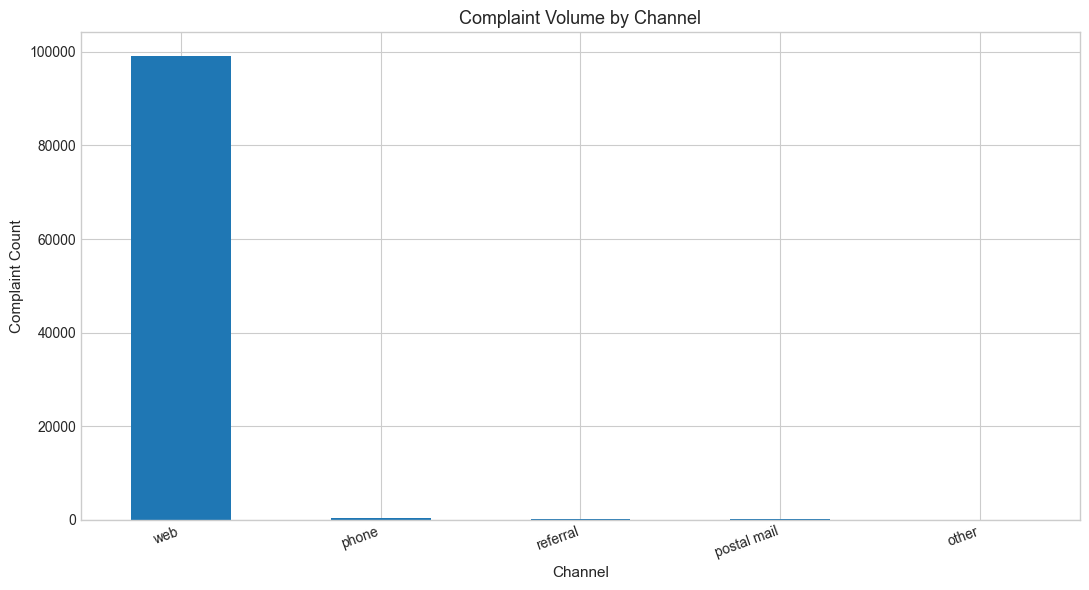

,channel_std,complaints,untimely_rate,avg_effort_proxy,heavy_channel_share
4,web,99212,0.0022,0.0616,0.0000
1,phone,407,0.0098,1.0098,1.0000
3,referral,191,0.0052,1.0052,1.0000
2,postal mail,186,0.0000,1.0000,1.0000
0,other,4,0.0000,0.0000,0.0000


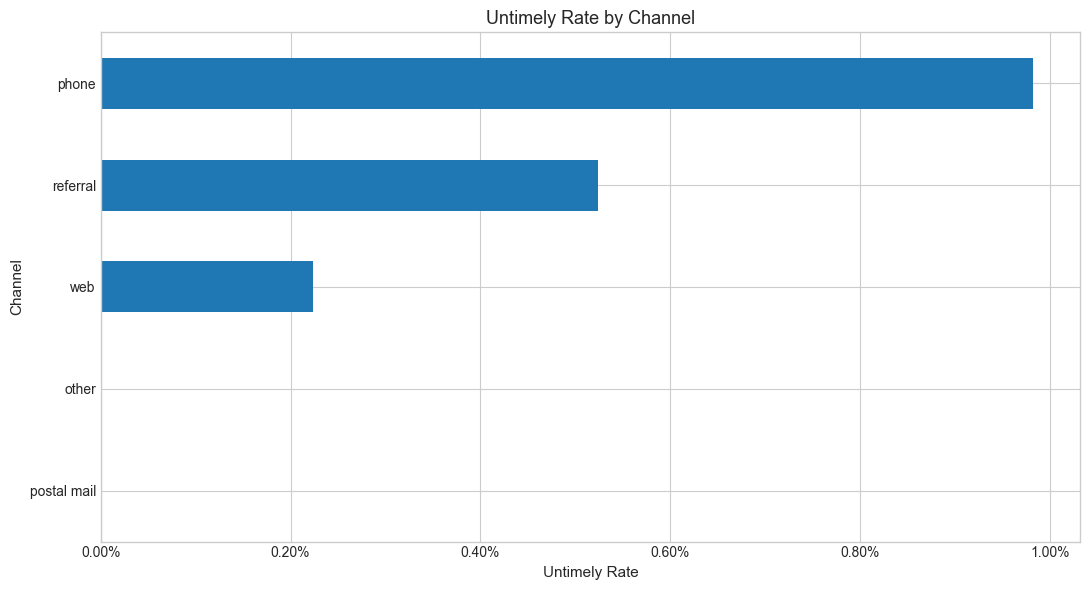

In [6]:
# %%
# Volume by channel
vol_channel = (
    df.groupby("channel_std", dropna=False)["complaint_id"]
      .count()
      .rename("complaints")
      .sort_values(ascending=False)
      .reset_index()
)
vol_channel["share"] = vol_channel["complaints"] / vol_channel["complaints"].sum()
display(vol_channel)

ax = vol_channel.plot(
    kind="bar",
    x="channel_std",
    y="complaints",
    legend=False,
    title="Complaint Volume by Channel"
)
ax.set_xlabel("Channel")
ax.set_ylabel("Complaint Count")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

# Risk and burden-proxy metrics by channel
channel_metrics = (
    df.groupby("channel_std", dropna=False)
      .agg(
          complaints=("complaint_id", "count"),
          untimely_rate=("untimely_flag", "mean"),
          avg_effort_proxy=("effort_score", "mean"),
          heavy_channel_share=("heavy_channel_flag", "mean"),
      )
      .reset_index()
      .sort_values("complaints", ascending=False)
)
display(channel_metrics)

ax = channel_metrics.sort_values("untimely_rate", ascending=True).plot(
    kind="barh",
    x="channel_std",
    y="untimely_rate",
    legend=False,
    title="Untimely Rate by Channel"
)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlabel("Untimely Rate")
ax.set_ylabel("Channel")
plt.tight_layout()
plt.show()

# Operational Burden Proxy Analysis

To avoid over-reliance on dispute-derived logic, this section emphasizes safer burden indicators:
- `heavy_channel_flag` share
- `narrative_length_chars` (as complexity signal)
- `untimely_flag` (risk indicator)
- `intake_to_routing_days` (process lag indicator)

`effort_score` is retained only as a **limited proxy** and interpreted cautiously.

,product_domain,complaints,heavy_channel_share,median_narrative_length,untimely_rate,median_intake_to_routing_days,avg_effort_proxy
1,Credit Reporting,91973,0.0044,641.0000,0.0011,0.0000,0.0579
2,Debt Collection,5414,0.0122,540.0000,0.0198,0.0000,0.1225
0,Checking / Savings,1959,0.1133,862.0000,0.0097,0.0000,0.3292
3,Mortgage,654,0.1361,"1,142.5000",0.0061,0.0000,0.4098


,issue_std,complaints,heavy_channel_share,median_narrative_length,untimely_rate,median_intake_to_routing_days,avg_effort_proxy
13,Incorrect information on your report,50233,0.0050,576.0000,0.0010,0.0000,0.0514
12,Improper use of your report,23545,0.0013,662.0000,0.0015,0.0000,0.0684
18,Problem with a company's investigation into an...,16099,0.0068,710.0000,0.0006,0.0000,0.0596
1,Attempts to collect debt not owed,2292,0.0131,565.0000,0.0223,0.0000,0.1239
27,Written notification about debt,1439,0.0146,308.0000,0.0111,0.0000,0.0966
19,Problem with a credit reporting company's inve...,1199,0.0008,577.0000,0.0008,0.0000,0.0759
14,Managing an account,1080,0.1509,955.0000,0.0102,0.0000,0.3833
9,False statements or representation,668,0.0045,"1,066.5000",0.0210,0.0000,0.1841
24,Took or threatened to take negative or legal a...,659,0.0106,741.0000,0.0258,0.0000,0.1108
25,Trouble during payment process,349,0.1519,"1,078.0000",0.0000,0.0000,0.4183


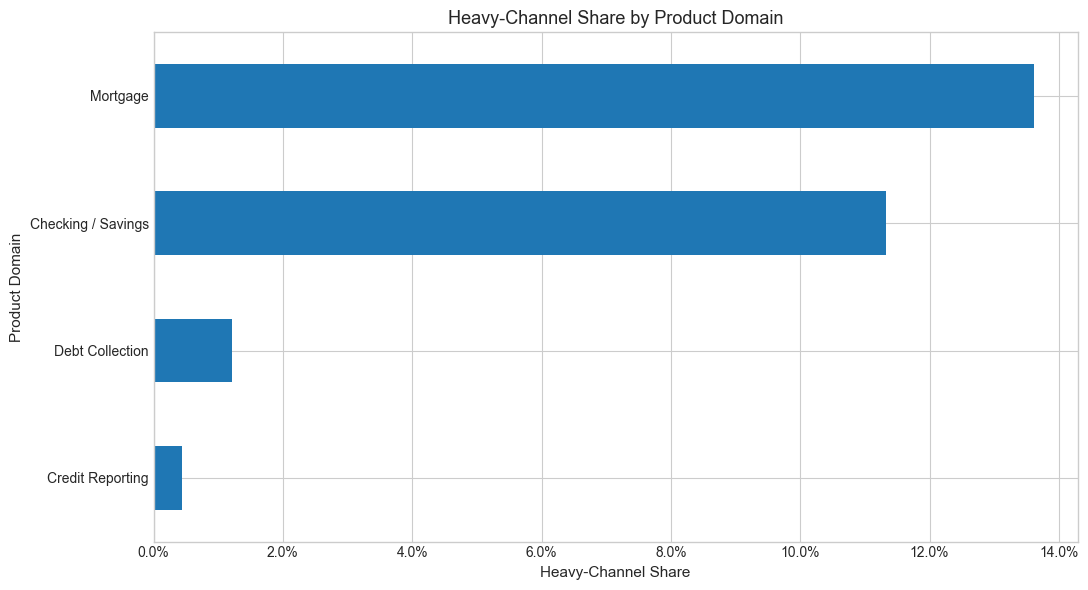

In [7]:
# %%
# Burden indicators by product domain
burden_by_product = (
    df.groupby("product_domain", dropna=False)
      .agg(
          complaints=("complaint_id", "count"),
          heavy_channel_share=("heavy_channel_flag", "mean"),
          median_narrative_length=("narrative_length_chars", "median"),
          untimely_rate=("untimely_flag", "mean"),
          median_intake_to_routing_days=("intake_to_routing_days", "median"),
          avg_effort_proxy=("effort_score", "mean"),
      )
      .reset_index()
      .sort_values("complaints", ascending=False)
)
display(burden_by_product.head(15))

# Burden indicators by issue (stability filter)
burden_by_issue = (
    df.groupby("issue_std", dropna=False)
      .agg(
          complaints=("complaint_id", "count"),
          heavy_channel_share=("heavy_channel_flag", "mean"),
          median_narrative_length=("narrative_length_chars", "median"),
          untimely_rate=("untimely_flag", "mean"),
          median_intake_to_routing_days=("intake_to_routing_days", "median"),
          avg_effort_proxy=("effort_score", "mean"),
      )
      .reset_index()
)
burden_by_issue = burden_by_issue[burden_by_issue["complaints"] >= 100].copy()
burden_by_issue = burden_by_issue.sort_values("complaints", ascending=False)

display(burden_by_issue.head(20))

ax = burden_by_product.head(10).sort_values("heavy_channel_share", ascending=True).plot(
    kind="barh",
    x="product_domain",
    y="heavy_channel_share",
    legend=False,
    title="Heavy-Channel Share by Product Domain"
)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlabel("Heavy-Channel Share")
ax.set_ylabel("Product Domain")
plt.tight_layout()
plt.show()

# Historical Age Composition Analysis

,age_bucket_hist,complaints,share
2,91–180,12156,0.1216
1,181–365,31893,0.3189
0,365+,55951,0.5595


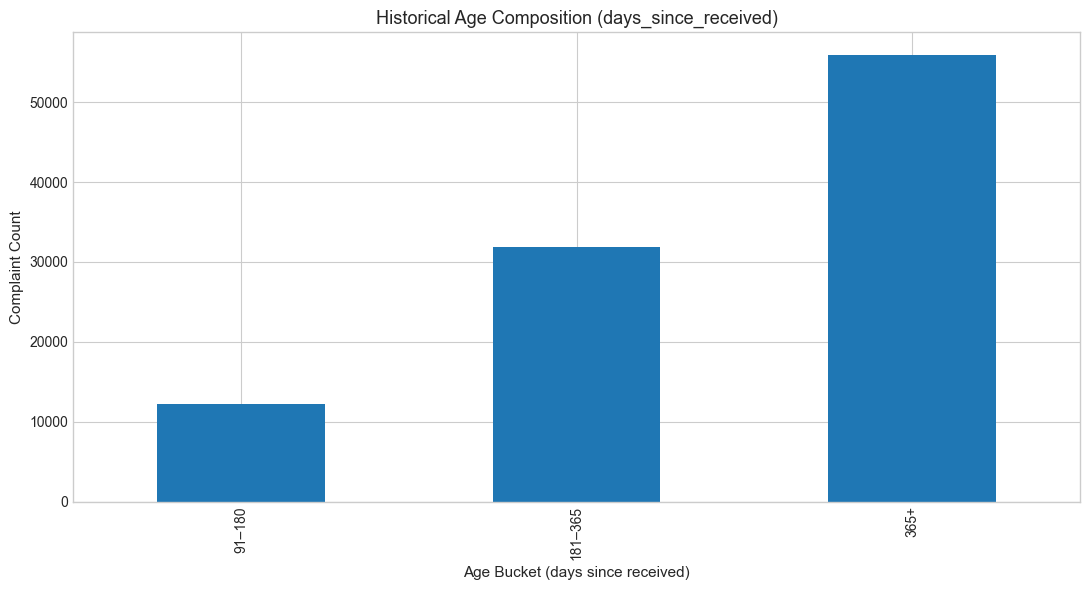

,product_domain,complaints
0,Credit Reporting,80467
1,Debt Collection,4912
2,Checking / Savings,1846
3,Mortgage,619


,issue_std,complaints
0,Incorrect information on your report,43261
1,Improper use of your report,21185
2,Problem with a company's investigation into an...,14010
3,Attempts to collect debt not owed,2116
4,Written notification about debt,1355
5,Problem with a credit reporting company's inve...,1199
6,Managing an account,1013
7,False statements or representation,598
8,Took or threatened to take negative or legal a...,514
9,Trouble during payment process,326


In [8]:
# %%
age_dist = (
    df["age_bucket_hist"].astype("string")
      .value_counts(dropna=False)
      .rename_axis("age_bucket_hist")
      .reset_index(name="complaints")
)

age_order = ["0–30", "31–90", "91–180", "181–365", "365+"]
age_dist["age_bucket_hist"] = pd.Categorical(age_dist["age_bucket_hist"], categories=age_order, ordered=True)
age_dist = age_dist.sort_values("age_bucket_hist")
age_dist["share"] = age_dist["complaints"] / age_dist["complaints"].sum()

display(age_dist)

ax = age_dist.plot(
    kind="bar",
    x="age_bucket_hist",
    y="complaints",
    legend=False,
    title="Historical Age Composition (days_since_received)"
)
ax.set_xlabel("Age Bucket (days since received)")
ax.set_ylabel("Complaint Count")
plt.tight_layout()
plt.show()

older_hist = df[df["age_bucket_hist"].astype("string").isin(["181–365", "365+"])].copy()

older_by_product = (
    older_hist.groupby("product_domain", dropna=False)["complaint_id"]
              .count()
              .rename("complaints")
              .sort_values(ascending=False)
              .reset_index()
)
display(older_by_product.head(12))

older_by_issue = (
    older_hist.groupby("issue_std", dropna=False)["complaint_id"]
              .count()
              .rename("complaints")
              .sort_values(ascending=False)
              .reset_index()
)
display(older_by_issue.head(15))

# Prioritization Matrix

A segment-level priority score is built for `(product_domain, issue_std, channel_std)` using normalized components:

- **complaints_norm (0.45)** → portfolio impact
- **untimely_rate_norm (0.35)** → risk concentration
- **burden_proxy_norm (0.15)** → operational burden signal
- **older_hist_share_norm (0.05)** → contextual signal only

Where:
`burden_proxy = 0.5 * heavy_channel_share + 0.5 * median_intake_to_routing_days_norm_within_set`

In [9]:
# %%
seg = (
    df.groupby(["product_domain", "issue_std", "channel_std"], dropna=False)
      .agg(
          complaints=("complaint_id", "count"),
          untimely_rate=("untimely_flag", "mean"),
          heavy_channel_share=("heavy_channel_flag", "mean"),
          median_intake_to_routing_days=("intake_to_routing_days", "median"),
          older_hist_share=("age_bucket_hist", lambda s: s.astype("string").isin(["181–365", "365+"]).mean()),
      )
      .reset_index()
)

# Stability filter
seg = seg[seg["complaints"] >= 75].copy()

# Fill median lag missing values for scoring robustness
seg["median_intake_to_routing_days"] = seg["median_intake_to_routing_days"].fillna(seg["median_intake_to_routing_days"].median())

# Normalize helper
def minmax(s):
    s_min = s.min()
    s_max = s.max()
    if pd.isna(s_min) or pd.isna(s_max) or s_max == s_min:
        return pd.Series(0.0, index=s.index)
    return (s - s_min) / (s_max - s_min)

seg["complaints_norm"] = minmax(seg["complaints"])
seg["untimely_rate_norm"] = minmax(seg["untimely_rate"])
seg["heavy_channel_share_norm"] = minmax(seg["heavy_channel_share"])
seg["median_intake_to_routing_days_norm"] = minmax(seg["median_intake_to_routing_days"])
seg["older_hist_share_norm"] = minmax(seg["older_hist_share"])

# Composite burden proxy (safer than dispute-centric logic)
seg["burden_proxy_norm"] = (
    0.5 * seg["heavy_channel_share_norm"] +
    0.5 * seg["median_intake_to_routing_days_norm"]
)

weights = {
    "complaints_norm": 0.45,
    "untimely_rate_norm": 0.35,
    "burden_proxy_norm": 0.15,
    "older_hist_share_norm": 0.05,
}

seg["priority_score"] = (
    seg["complaints_norm"] * weights["complaints_norm"]
    + seg["untimely_rate_norm"] * weights["untimely_rate_norm"]
    + seg["burden_proxy_norm"] * weights["burden_proxy_norm"]
    + seg["older_hist_share_norm"] * weights["older_hist_share_norm"]
)

priority_cols = [
    "product_domain",
    "issue_std",
    "channel_std",
    "complaints",
    "untimely_rate",
    "heavy_channel_share",
    "median_intake_to_routing_days",
    "older_hist_share",
    "priority_score",
]
priority_ranked = seg.sort_values("priority_score", ascending=False)[priority_cols].reset_index(drop=True)

display(priority_ranked.head(20))

,product_domain,issue_std,channel_std,complaints,untimely_rate,heavy_channel_share,median_intake_to_routing_days,older_hist_share,priority_score
0,Credit Reporting,Incorrect information on your report,web,49962,0.0010,0.0000,0.0000,0.8607,0.4736
1,Debt Collection,Electronic communications,web,80,0.0625,0.0000,0.0000,0.9500,0.3886
2,Checking / Savings,Managing an account,referral,92,0.0109,1.0000,1.0000,0.9783,0.2560
3,Credit Reporting,Improper use of your report,web,23509,0.0015,0.0000,0.0000,0.8997,0.2468
4,Debt Collection,Attempts to collect debt not owed,web,2262,0.0212,0.0000,0.0000,0.9222,0.1708
5,Mortgage,Struggling to pay mortgage,web,130,0.0231,0.0000,0.0000,0.9538,0.1692
6,Credit Reporting,Problem with a company's investigation into an...,web,15981,0.0006,0.0000,0.0000,0.8697,0.1669
7,Debt Collection,Took or threatened to take negative or legal a...,web,652,0.0261,0.0000,0.0000,0.7807,0.1512
8,Debt Collection,False statements or representation,web,665,0.0211,0.0000,0.0000,0.8962,0.1495
9,Checking / Savings,Closing an account,web,257,0.0156,0.0000,0.0000,0.9416,0.1255


# Key Highlights

This analysis shows that complaint volume is highly concentrated in a small number of areas rather than being evenly spread across the portfolio. Credit Reporting is by far the largest product domain, making up most of the complaints in the scoped dataset. Within that domain, the biggest issues are incorrect information on a report, improper use of a report, and problems with company investigations. This means the main operational pressure comes from a few recurring complaint types, not from all products equally.

At the same time, overall timeliness looks very strong. The timely rate is extremely high, and the untimely rate is low across the full dataset. However, when the results are broken down by product and issue, some pockets of higher risk become visible. Debt Collection shows a higher untimely rate than the other major domains, and certain issue groups within Debt Collection appear more operationally sensitive than the portfolio average.

The channel analysis adds another important point. Most complaints come through the web channel, so web clearly drives total workload. But smaller channels such as phone, referral, and postal mail appear to carry higher burden signals. Even though their volume is low, they may require more manual handling or special attention compared with standard web complaints.

The burden indicators also suggest that lower-volume areas should not be ignored. Mortgage and Checking / Savings complaints tend to show longer narratives and higher heavy-channel shares, which may indicate greater complexity. In other words, some smaller segments may create more effort per case even if they do not dominate total counts.

The historical age analysis shows that a large share of records fall into older age buckets. These older complaints are still concentrated in the same major domains and issues, especially Credit Reporting. This suggests that the dominant complaint types are not only large in volume, but also continue to shape the historical complaint profile over time.

Finally, the prioritization analysis helps combine these findings into a practical view. It shows that the highest-priority segments are not only the biggest segments, but also selected smaller segments where risk or burden is relatively higher. That makes the prioritization more useful for decision-making than using complaint count alone.

#  Recommendations

The first recommendation is to focus operational improvement efforts on the highest-volume Credit Reporting issues. Since most complaints are concentrated in a few recurring issue types, even a small improvement in routing, standardization, or handling efficiency in these areas could produce a meaningful impact across the whole portfolio.

The second recommendation is to monitor Debt Collection more closely as a higher-risk area. Although it represents a much smaller share of total complaints than Credit Reporting, it has a comparatively higher untimely rate. This means it may deserve more targeted review instead of being judged only through overall portfolio averages.

A third recommendation is to treat smaller non-web channels as distinct workflows rather than handling them exactly the same way as web complaints. Phone, referral, and postal mail appear low in volume but higher in burden signals, so they may benefit from more specialized processes, staffing attention, or escalation rules.

Another important step is to review Mortgage and Checking / Savings segments for complexity. These areas tend to show longer narratives and higher heavy-channel shares, which suggests that some complaints may be more detailed or operationally difficult even if the total number is not large. These segments could be good candidates for process review or targeted case sampling.

The prioritization matrix should also be used as a decision-support tool. Instead of focusing only on complaint volume, management can use it to balance scale, untimely risk, and operational burden when deciding where to allocate attention and improvement resources.

Lastly, reporting should separate portfolio-level results from segment-level risk. The overall timely rate is very strong, but that high-level result can hide important variation underneath. A dashboard or management summary that combines both overall KPIs and segmented risk views would give a clearer picture of where action is actually needed.

# Limitations

This analysis is based on cleaned CFPB complaint records after ETL, which makes it useful for portfolio-level operational review, but it does not provide full internal workflow visibility. The data does not include queue movement, staffing assignments, handoffs, or full resolution lifecycle information, so the results should be interpreted as operational signals rather than complete workflow measurement.

Another limitation is that the historical age measure should not be treated as true backlog or resolution duration. It reflects elapsed time since the complaint was received relative to the analysis date, not the actual amount of time the complaint stayed active in an internal process.

The timely and untimely indicators are also limited. They are helpful for identifying risk patterns, but they do not fully capture internal service performance or all aspects of operational quality. They should be treated as outcome indicators rather than complete SLA measurements.

The effort score used in the analysis is a derived proxy, not a direct measure of labor, cost, or true processing time. It is useful for comparing segments at a high level, but it should be interpreted carefully and not as an exact measure of operational effort.

A final limitation is that the notebook shown here uses a sample file rather than the full production-sized dataset. The main patterns are still strong and useful, but exact counts, rankings, and some smaller segment results may change slightly when the full scoped dataset is used.